# FDPs del simulador: del dataset al catálogo `config/fdp_v2.toml`

**TP5 Simulación · Grupo 6 · cantidad óptima de choferes (Lyft, Boston)**

Este notebook documenta, paso a paso, de dónde sale cada una de las cinco funciones de densidad de probabilidad (FDP) que usa el simulador, y genera los valores del catálogo `config/fdp_v2.toml`. Es el único notebook vigente del repositorio: reemplaza a los notebooks del TP4.

| Variable | Qué es | De dónde sale | FDP elegida |
|---|---|---|---|
| IA | Intervalo entre pedidos (min) | **Supuesto** (el dataset no sirve para esto, ver sección 2) | Exponencial, media 2,5 |
| TB | Tiempo de búsqueda: hasta que el chofer llega al cliente (min) | **Supuesto** (no está en el dataset) | Gamma, media 5 y desvío 1,5 |
| DEM | Demora por tráfico (min) | **Supuesto** (no está en el dataset) | Exponencial, media 0,8 |
| D | Distancia del viaje (millas) | **Dataset** | Weibull |
| TAR | Tarifa (USD) | **Dataset** | Normal asimétrica |

El tiempo de viaje no tiene FDP propia: el simulador lo calcula como TV = D × 60 / v + DEM, con v = 13 mi/h (sección 8).

**Cómo leerlo.** Cada sección explica qué es la variable, de dónde sale, qué se probó, qué se eligió y cómo se verificó. Las reglas que se siguen están en el modelo (`docs/modelo.md`, sección 4.3) y el formato del catálogo, en el SDD (`docs/sdd.md`, sección 5.6).

**Cómo correrlo.** De arriba hacia abajo, desde la carpeta `notebooks/`. Necesita el dataset en `data/raw/dataset-uber_lyft.csv` (ver `data/README.md`) y las bibliotecas de `requirements.txt`. No usa Fitter: hace el mismo cálculo con scipy (sección 1.2) y así da los mismos números que Fitter, sin sus problemas de dependencias en Colab.

## Qué cambió respecto del notebook del TP4

Para quienes trabajaron con `NotebookFDPs.ipynb` o `viajesLyft-Grupo 6 - TP4.ipynb`:

| Tema | Notebook del TP4 | Este notebook | Por qué |
|---|---|---|---|
| **Distancia** | `dgamma` (la de menor error cuadrático entre todas las familias) | **Weibull**, elegida entre lognormal, gamma y Weibull | La `dgamma` genera distancias negativas (sección 6.4). La Weibull es la misma que ya había encontrado el notebook `viajesLyft-Grupo 6 - TP4`: acá se reproduce y se verifica |
| **Tarifa** | `johnsonsb` con media 17,28 USD, con parámetros copiados a mano | **Normal asimétrica** con media 9,28 USD | La media de 17,28 sale de mezclar todos los productos de Lyft (Lux, XL, Shared…). El modelo pide el producto estándar `Lyft` sin recargo dinámico, que cuesta en promedio 9,28 (sección 7) |
| **Duración del viaje** | Se ajustaba una `nakagami` a duraciones calculadas con una velocidad aleatoria | **Se eliminó** | Ajustar una FDP a datos que generamos nosotros solo devuelve lo que pusimos (modelo §4.3). El simulador calcula el tiempo de viaje a partir de la distancia (sección 8) |
| **Regresión tarifa ~ distancia** | Se ajustaba una FDP a los residuos | **Se eliminó** de este notebook | Es de la segunda iteración (modelo §4.5.6). Además, los residuos tienen signo y necesitan familias que admitan negativos (normal, t, Laplace o logística), no lognormal o gamma |
| **Criterio de elección** | Menor error cuadrático (`sumsquare_error`) | **Menor BIC** más gráfico QQ | El BIC penaliza las familias con más parámetros; el QQ muestra dónde ajusta mal. El p-valor de Kolmogorov-Smirnov no sirve: con decenas de miles de datos rechaza todo (modelo §4.3) |
| **Parámetros** | Copiados a mano en celdas aparte | **Leídos del ajuste**, y comparados con el catálogo al final (sección 9) | Evita errores de copia |
| **Datos** | Google Drive (Colab) | Ruta relativa al repositorio | Cualquiera puede correrlo con el repositorio clonado |
| **Familias de la distancia** | Todas las de scipy, incluidas las que admiten negativos | Solo las de soporte positivo | Una distancia negativa detiene el simulador (modelo §4.3) |
| **Intervalo entre pedidos, búsqueda y demora** | Supuestos (igual que acá) | Sin cambios; se explica por qué son supuestos | — |

## 1. Preparación

### 1.1 Bibliotecas, semilla y datos

La semilla solo afecta a las muestras de verificación de este notebook (10.000 valores por variable). Es la misma semilla base del simulador (modelo §9.2), pero el simulador no usa nada de lo que se genera acá: lee solo el catálogo.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")              # scipy avisa cuando un ajuste no converge bien en alguna familia
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})
GRIS = "0.65"                                  # gráficos en blanco y negro, como pide el formato de la cátedra

SEMILLA = 20261002
RUTA_DATOS = "../data/raw/dataset-uber_lyft.csv"
RUTA_CATALOGO = "../config/fdp_v2.toml"

COLUMNAS = ["id", "timestamp", "source", "destination", "cab_type", "name", "price", "distance", "surge_multiplier"]
viajes = pd.read_csv(RUTA_DATOS, usecols=COLUMNAS)
print(f"Filas: {len(viajes):,} | columnas usadas: {len(COLUMNAS)} de 57")

Filas: 693,071 | columnas usadas: 9 de 57


### 1.2 Cómo se ajusta y se elige una FDP

Para cada familia candidata:

1. Se estiman sus parámetros por máxima verosimilitud, con `dist.fit(datos)` de scipy.
2. Se calcula la log-verosimilitud logL y el **BIC = k · ln(n) − 2 · logL**, donde k es la cantidad de parámetros y n la de datos. Cuanto menor el BIC, mejor el ajuste; el término k · ln(n) penaliza a las familias con más parámetros.
3. Se ordena por BIC, se elige la primera y se mira su **gráfico QQ**: cuantiles teóricos contra cuantiles de los datos. Si los puntos siguen la diagonal, la FDP reproduce bien la forma de los datos.

Es exactamente lo que hace `Fitter.get_best(method="bic")`: en la sección 6 se comprueba que da los mismos números que obtuvo Fitter en el notebook del TP4.

In [2]:
def ajustar(datos, familias):
    """Ajusta cada familia por máxima verosimilitud y las ordena por BIC (de mejor a peor)."""
    datos = np.asarray(datos, dtype=float)
    n = len(datos)
    filas = []
    for familia in familias:
        dist = getattr(stats, familia)
        params = dist.fit(datos)
        logL = np.sum(dist.logpdf(datos, *params))
        k = len(params)
        filas.append({"familia": familia, "params": tuple(float(p) for p in params),
                      "aic": 2 * k - 2 * logL, "bic": k * np.log(n) - 2 * logL})
    return pd.DataFrame(filas).sort_values("bic").reset_index(drop=True)


def nombres_parametros(familia):
    """Nombres de scipy para los parámetros de una familia: los de forma, después loc y scale."""
    forma = getattr(stats, familia).shapes
    return ([s.strip() for s in forma.split(",")] if forma else []) + ["loc", "scale"]


def grafico_qq(ax, datos, dist, titulo):
    q = np.linspace(0.005, 0.995, 199)
    teoricos, empiricos = dist.ppf(q), np.quantile(datos, q)
    ax.scatter(teoricos, empiricos, s=8, color="black")
    lim = [min(teoricos.min(), empiricos.min()), max(teoricos.max(), empiricos.max())]
    ax.plot(lim, lim, "k--", linewidth=1)
    ax.set(title=titulo, xlabel="cuantiles teóricos", ylabel="cuantiles de los datos")


def verificar(dist, datos=None, minimo_estricto=None, tol_media=None, tol_desvio=None):
    """Criterios de aceptación del modelo (§4.5): sin negativos en 10.000 valores y media (y desvío) cerca de los datos."""
    muestra = dist.rvs(10_000, random_state=np.random.default_rng(SEMILLA))
    print(f"Muestra de 10.000: mínimo {muestra.min():.4f} | máximo {muestra.max():.4f} | negativos: {(muestra < 0).sum()}")
    if minimo_estricto is not None:
        print(f"Valores ≤ {minimo_estricto}: {(muestra <= minimo_estricto).sum()}")
    if datos is not None:
        for nombre, gen, dat, tol in [("media", muestra.mean(), np.mean(datos), tol_media),
                                      ("desvío", muestra.std(), np.std(datos, ddof=1), tol_desvio)]:
            if tol is None:
                continue
            dif = 100 * (gen / dat - 1)
            print(f"{nombre}: generada {gen:.4f} | datos {dat:.4f} | diferencia {dif:+.2f} % "
                  f"(tolerancia ±{tol} %) → {'cumple' if abs(dif) <= tol else 'NO CUMPLE'}")
    return muestra

## 2. El dataset: qué contiene y qué no

El dataset de Kaggle *"Uber and Lyft Dataset Boston, MA"* (noviembre y diciembre de 2018) **no registra viajes**: registra **cotizaciones**. Un script consultaba periódicamente las APIs de Uber y Lyft con un origen y un destino, y guardaba el precio que devolvía cada producto. Esto tiene tres consecuencias:

1. **No sirve para el intervalo entre pedidos.** Los timestamps marcan cuándo corría el script, no cuándo pedía un viaje una persona.
2. **Hay que deduplicar para la distancia.** Cada consulta devuelve una fila por producto (Lyft, Lyft XL, Lux…), con la misma distancia. El archivo de Kaggle es una muestra del original y de cada consulta conserva entre uno y varios productos; si no se deduplica, una consulta pesa más o menos según cuántas de sus filas quedaron. En el 4,5 % de los grupos aparecen distancias distintas: son consultas diferentes que cayeron en el mismo segundo y la misma ruta. La deduplicación se queda con una; el control de la sección 6.1 muestra que eso no cambia la distribución.
3. **El precio sí sirve**, pero hay que elegir un producto y descartar el recargo dinámico.

In [3]:
print("Filas por empresa:")
print(viajes["cab_type"].value_counts().to_string())
lyft = viajes[viajes["cab_type"] == "Lyft"]
print(f"\nLyft: {len(lyft):,} filas | orígenes distintos: {lyft['source'].nunique()} | destinos distintos: {lyft['destination'].nunique()}")
print("\nFilas de Lyft por producto:")
print(lyft["name"].value_counts().to_string())

Filas por empresa:
cab_type
Uber    385663
Lyft    307408

Lyft: 307,408 filas | orígenes distintos: 12 | destinos distintos: 12

Filas de Lyft por producto:
name
Lux             51235
Lyft            51235
Lux Black XL    51235
Lyft XL         51235
Lux Black       51235
Shared          51233


In [4]:
# Una consulta = un timestamp con un origen y un destino. En el archivo quedaron entre 1 y varias filas (productos) por consulta.
filas_por_consulta = lyft.groupby(["timestamp", "source", "destination"]).size()
print(f"Consultas distintas: {len(filas_por_consulta):,}")
print("Filas por consulta (cuántas consultas tienen 1, 2, … filas):")
print(filas_por_consulta.value_counts().sort_index().head(8).to_string())

# ¿La distancia es la misma para todas las filas de una consulta?
rango = lyft.groupby(["timestamp", "source", "destination"])["distance"].agg(lambda d: d.max() - d.min())
print(f"\nConsultas con distancias distintas entre productos: {(rango > 0).sum():,} ({(rango > 0).mean():.1%}); "
      f"diferencia máxima: {rango.max():.2f} mi")

Consultas distintas: 131,232
Filas por consulta (cuántas consultas tienen 1, 2, … filas):
1    64319
2    17840
3    15770
4    14382
5    13279
6     4539
7      511
8      262

Consultas con distancias distintas entre productos: 5,950 (4.5%); diferencia máxima: 2.65 mi


In [5]:
# Por qué el dataset no sirve para el intervalo entre pedidos: los timestamps miden el ritmo del script.
t = np.sort(lyft["timestamp"].unique())
dif_seg = np.diff(t)
print(f"Timestamps distintos de Lyft: {len(t):,} en {(t[-1] - t[0]) / 86400:.1f} días")
print(f"Separación entre timestamps consecutivos: mediana {np.median(dif_seg):.1f} s | media {dif_seg.mean():.1f} s")
print("Si fueran pedidos de una zona, habría un pedido cada pocos segundos todo el día, sin horas pico: es el script.")

Timestamps distintos de Lyft: 31,419 en 22.6 días
Separación entre timestamps consecutivos: mediana 1.0 s | media 62.3 s
Si fueran pedidos de una zona, habría un pedido cada pocos segundos todo el día, sin horas pico: es el script.


## 3. Intervalo entre pedidos (IA): supuesto

**Qué es.** El tiempo entre un pedido y el siguiente, en minutos.

**De dónde sale.** Es un **supuesto** (decisión D-01 del modelo), porque el dataset no tiene pedidos reales (sección 2). Se asumen llegadas de Poisson, es decir, intervalos **exponenciales**, con media **2,5 minutos** (λ = 0,4 pedidos por minuto). El orden de magnitud se contrastó con el informe del Departamento de Servicios Públicos de Massachusetts (DPU): unos 42 millones de viajes en Boston en 2018 (modelo §4.1 y D-01).

**Niveles de demanda.** El experimento prueba tres niveles multiplicando λ: bajo (× 0,7), base y alto (× 1,3). La media del intervalo se divide por el factor.

**En el catálogo.** No va: su media está en `config/experimento.toml` y el simulador la escala según el nivel.

bajo  → media 3.571 min | 403 pedidos esperados por día
base  → media 2.500 min | 576 pedidos esperados por día
alto  → media 1.923 min | 749 pedidos esperados por día


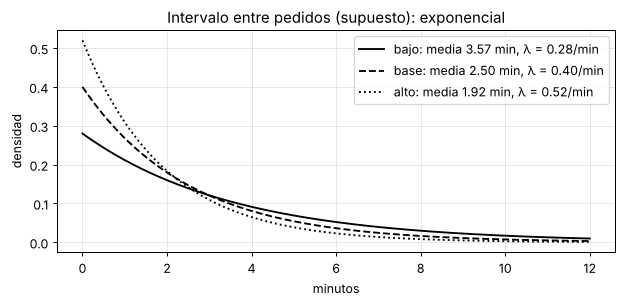

In [6]:
MEDIA_IA_BASE = 2.5
niveles = {"bajo": 0.7, "base": 1.0, "alto": 1.3}
fig, ax = plt.subplots(figsize=(8, 3.2))
x = np.linspace(0, 12, 300)
for (nivel, factor), estilo in zip(niveles.items(), ["-", "--", ":"]):
    media = MEDIA_IA_BASE / factor
    ax.plot(x, stats.expon(scale=media).pdf(x), "k" + estilo, label=f"{nivel}: media {media:.2f} min, λ = {factor / MEDIA_IA_BASE:.2f}/min")
    print(f"{nivel:5s} → media {media:.3f} min | {1440 / media:.0f} pedidos esperados por día")
ax.set(title="Intervalo entre pedidos (supuesto): exponencial", xlabel="minutos", ylabel="densidad"); ax.legend()
plt.show()

## 4. Tiempo de búsqueda (TB): supuesto

**Qué es.** El tiempo desde que se asigna un chofer hasta que llega a buscar al cliente, en minutos.

**De dónde sale.** El dataset no lo tiene. Es un **supuesto**: media 5 minutos y desvío 1,5. Se modela con una **gamma**, que solo da valores positivos. Sus parámetros salen de la media m y el desvío s: forma a = (m / s)² y escala = s² / m.

**Por qué no una normal recortada.** La versión anterior usaba `max(1, N(5; 1,5))`. El recorte acumula en el valor 1 toda la probabilidad de la cola izquierda y crea un pico artificial (modelo §4.3). La gamma no tiene ese problema.

gamma: a = 11.111111111111112, scale = 0.45 → media 5.0000, desvío 1.5000
Muestra de 10.000: mínimo 1.0963 | máximo 14.1605 | negativos: 0
Valores ≤ 0: 0


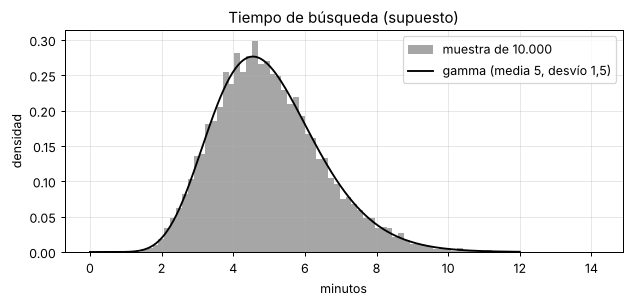

In [7]:
m, s = 5.0, 1.5
a_tb, escala_tb = (m / s) ** 2, s ** 2 / m
dist_tb = stats.gamma(a_tb, scale=escala_tb)
print(f"gamma: a = {a_tb!r}, scale = {escala_tb!r} → media {dist_tb.mean():.4f}, desvío {dist_tb.std():.4f}")
muestra_tb = verificar(dist_tb, minimo_estricto=0)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(muestra_tb, bins=80, density=True, color=GRIS, label="muestra de 10.000")
x = np.linspace(0, 12, 300)
ax.plot(x, dist_tb.pdf(x), "k", label="gamma (media 5, desvío 1,5)")
ax.set(title="Tiempo de búsqueda (supuesto)", xlabel="minutos", ylabel="densidad"); ax.legend()
plt.show()

## 5. Demora por tráfico (DEM): supuesto

**Qué es.** Minutos que se suman al tiempo de viaje por el tránsito, además de lo que tarda recorrer la distancia a velocidad media.

**De dónde sale.** El dataset no tiene duraciones. Es un **supuesto**: **exponencial con media 0,8 minutos**. La mayoría de los viajes casi no se demoran, y pocos se demoran bastante. La versión anterior era `max(0, N(0; 2))`, que pone la mitad de los viajes exactamente en 0 (el mismo problema del recorte de la sección 4).

In [8]:
dist_dem = stats.expon(scale=0.8)
print(f"exponencial: scale = 0.8 → media {dist_dem.mean():.2f} min | P(demora > 3 min) = {dist_dem.sf(3):.3f}")
muestra_dem = verificar(dist_dem)

exponencial: scale = 0.8 → media 0.80 min | P(demora > 3 min) = 0.024
Muestra de 10.000: mínimo 0.0001 | máximo 6.8283 | negativos: 0


## 6. Distancia (D): ajuste al dataset

### 6.1 Datos

Una fila por **consulta** (sección 2): Lyft, deduplicado por timestamp, origen y destino. Sin deduplicar, cada consulta contaría varias veces, una por producto.

Consultas: 131,232 (de 307,408 filas de Lyft)
count    131232.000
mean          2.191
std           1.087
min           0.390
25%           1.270
50%           2.150
75%           2.980
max           6.330
Rutas origen-destino distintas: 72
Control: con una sola fila por consulta del producto Lyft (51,235 filas), media 2.187 y desvío 1.087: la forma de deduplicar no cambia la distribución


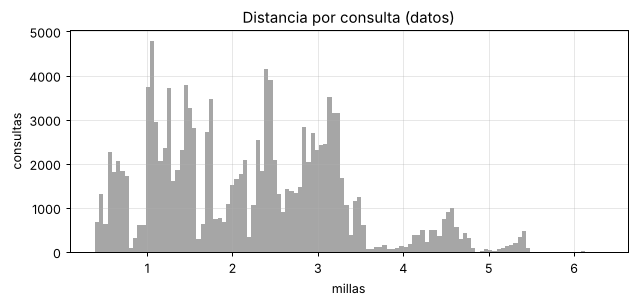

In [9]:
lyft_dist = lyft.drop_duplicates(subset=["timestamp", "source", "destination"])
distancias = lyft_dist["distance"].to_numpy()
print(f"Consultas: {len(distancias):,} (de {len(lyft):,} filas de Lyft)")
print(pd.Series(distancias).describe().round(3).to_string())
print(f"Rutas origen-destino distintas: {lyft_dist.groupby(['source', 'destination']).ngroups}")
otra = lyft.loc[lyft["name"] == "Lyft", "distance"]
print(f"Control: con una sola fila por consulta del producto Lyft ({len(otra):,} filas), media {otra.mean():.3f} y desvío {otra.std():.3f}: la forma de deduplicar no cambia la distribución")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(distancias, bins=120, color=GRIS)
ax.set(title="Distancia por consulta (datos)", xlabel="millas", ylabel="consultas")
plt.show()

El histograma tiene varios picos: las distancias salen de 72 rutas fijas entre 12 barrios, no de viajes con origen y destino libres. Ninguna familia continua va a reproducir esos picos; se busca la que mejor aproxime la forma general, y la diferencia se declara como limitación (modelo §12.2).

### 6.2 Ajuste

Solo familias con soporte positivo (modelo §4.3): lognormal, gamma y Weibull.

In [10]:
ajuste_d = ajustar(distancias, ["lognorm", "gamma", "weibull_min"])
print(ajuste_d[["familia", "aic", "bic"]].to_string(index=False))
fam_d, par_d = ajuste_d.loc[0, "familia"], ajuste_d.loc[0, "params"]
dist_d = getattr(stats, fam_d)(*par_d)
print(f"\nElegida por BIC: {fam_d}")
for nombre, valor in zip(nombres_parametros(fam_d), par_d):
    print(f"  {nombre} = {valor!r}")

    familia           aic           bic
weibull_min 376760.177182 376789.531348
      gamma 381361.009688 381390.363854
    lognorm 384004.392707 384033.746873

Elegida por BIC: weibull_min
  c = 1.7369116327905525
  loc = 0.3309934599319153
  scale = 2.083267038112721


Los AIC y BIC coinciden con los que dio Fitter en el notebook `viajesLyft-Grupo 6 - TP4` (Weibull: 376760,18 y 376789,53), así que el cálculo de la sección 1.2 es equivalente.

**El parámetro `loc` de la Weibull es la distancia mínima posible:** 0,33 millas. Al ser positivo, la FDP no puede dar distancias negativas ni nulas. La distancia mínima de los datos es 0,39.

### 6.3 Gráficos y verificación

Criterios del modelo (§4.5.1): ningún valor ≤ 0 en 10.000 generados y media generada a ±2 % de la de los datos.

Muestra de 10.000: mínimo 0.3437 | máximo 7.7701 | negativos: 0
Valores ≤ 0: 0
media: generada 2.1955 | datos 2.1908 | diferencia +0.22 % (tolerancia ±2 %) → cumple
desvío: generada 1.1057 | datos 1.0874 | diferencia +1.68 % (tolerancia ±5 %) → cumple


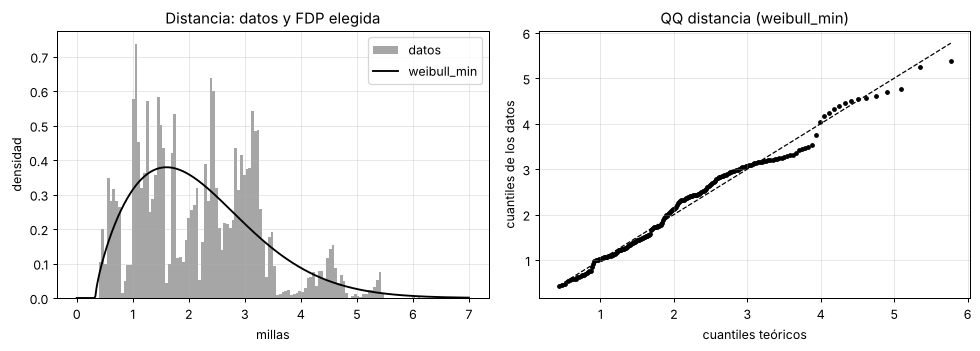

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(distancias, bins=120, density=True, color=GRIS, label="datos")
x = np.linspace(0, 7, 400)
ax1.plot(x, dist_d.pdf(x), "k", label=fam_d)
ax1.set(title="Distancia: datos y FDP elegida", xlabel="millas", ylabel="densidad"); ax1.legend()
grafico_qq(ax2, distancias, dist_d, f"QQ distancia ({fam_d})")
plt.tight_layout(); plt.show()

muestra_d = verificar(dist_d, datos=distancias, minimo_estricto=0, tol_media=2, tol_desvio=5)

El QQ sigue la diagonal en la parte central y se aparta en algunos tramos, por los picos de las rutas fijas. La media y el desvío se reproducen bien, que es lo que importa para el simulador: la distancia media define el tiempo medio de servicio E[S] y, con él, las flotas de referencia.

### 6.4 Por qué no la `dgamma` del TP4

El notebook del TP4 eligió una `dgamma` (gamma doble) por menor error cuadrático entre todas las familias de scipy. La `dgamma` es simétrica y admite valores a ambos lados de `loc`, así que genera distancias negativas:

In [12]:
dgamma_tp4 = stats.dgamma(1.9598662147932329, loc=1.9257140205633956, scale=0.46862641746854794)   # parámetros del TP4
print(f"P(distancia < 0)    = {dgamma_tp4.cdf(0):.3%}")
print(f"P(distancia < 0,39) = {dgamma_tp4.cdf(0.39):.3%}  (0,39 es la distancia mínima de los datos)")
print(f"Con unos 576 pedidos por día, saldrían {576 * dgamma_tp4.cdf(0):.0f} viajes con distancia negativa por día: el simulador se detendría.")

P(distancia < 0)    = 3.991%
P(distancia < 0,39) = 7.732%  (0,39 es la distancia mínima de los datos)
Con unos 576 pedidos por día, saldrían 23 viajes con distancia negativa por día: el simulador se detendría.


## 7. Tarifa (TAR): ajuste al dataset

### 7.1 Qué precios se usan

El modelo pide el producto estándar **`Lyft`** y **sin recargo dinámico** (`surge_multiplier == 1`, supuesto S-10): el simulador no modela horas pico, así que tampoco el recargo que se cobra en ellas. En la primera iteración, la tarifa no depende de la distancia (S-14).

Primero, por qué la media del TP4 (17,28 USD) no corresponde al producto estándar:

In [13]:
resumen_productos = lyft.groupby("name")["price"].agg(filas="count", media="mean").round(2).sort_values("media")
print(resumen_productos.to_string())
print(f"\nTodos los productos de Lyft mezclados: media {lyft['price'].mean():.2f} USD ← de ahí venía el 17,28 del TP4")

lyft_estandar = lyft[lyft["name"] == "Lyft"]
print(f"\nProducto Lyft, por recargo dinámico:")
print(lyft_estandar.groupby("surge_multiplier")["price"].agg(filas="count", media="mean").round(2).to_string())

              filas  media
name                      
Shared        51233   6.03
Lyft          51235   9.61
Lyft XL       51235  15.31
Lux           51235  17.77
Lux Black     51235  23.06
Lux Black XL  51235  32.32

Todos los productos de Lyft mezclados: media 17.35 USD ← de ahí venía el 17,28 del TP4

Producto Lyft, por recargo dinámico:
                  filas  media
surge_multiplier              
1.00              47040   9.28
1.25               2217  11.51
1.50               1013  13.73
1.75                484  15.66
2.00                398  17.33
2.50                 77  22.52
3.00                  6  29.75


In [14]:
lyft_std = lyft_estandar[lyft_estandar["surge_multiplier"] == 1.0]
precios = lyft_std["price"].dropna().to_numpy()
print(f"Precios usados: {len(precios):,} (precios nulos descartados: {lyft_std['price'].isna().sum()})")
print(pd.Series(precios).describe().round(3).to_string())

valores, cantidades = np.unique(precios, return_counts=True)
print("\nLos precios toman muy pocos valores distintos:")
print(pd.DataFrame({"precio (USD)": valores, "filas": cantidades, "%": (100 * cantidades / len(precios)).round(2)}).to_string(index=False))

Precios usados: 47,040 (precios nulos descartados: 0)
count    47040.000
mean         9.281
std          2.066
min          5.000
25%          7.000
50%          9.000
75%         10.500
max         19.500

Los precios toman muy pocos valores distintos:
 precio (USD)  filas     %
         5.00    129  0.27
         7.00  16106 34.24
         7.98      1  0.00
         8.35      1  0.00
         9.00  11031 23.45
         9.35      1  0.00
        10.50   9762 20.75
        11.00   5670 12.05
        13.50   4187  8.90
        16.50    151  0.32
        19.50      1  0.00


Los precios son **escalonados**: salen de una tabla de tarifas por ruta y casi todos valen 7, 9, 10,5, 11 o 13,5 USD. Una FDP continua no puede reproducir esos escalones: se busca la que reproduzca bien la media, el desvío y la asimetría, y la diferencia se declara como limitación (modelo §12.2). Como la tarifa no interviene en la decisión de flota, solo afecta a la recaudación.

### 7.2 Ajuste

Se prueban 21 familias. Algunas (normal, normal asimétrica, Gumbel…) admiten valores negativos: se aceptan solo si la probabilidad de un valor negativo es despreciable, `cdf(0)` < 10⁻⁹ (modelo §4.3).

In [15]:
familias_t = ["johnsonsb", "johnsonsu", "lognorm", "gamma", "weibull_min", "burr", "burr12", "fisk", "gengamma",
              "exponweib", "invgauss", "genlogistic", "norm", "beta", "genextreme", "mielke", "nakagami",
              "gumbel_r", "betaprime", "loglaplace", "skewnorm"]
ajuste_t = ajustar(precios, familias_t)
ajuste_t["cdf(0)"] = [getattr(stats, f).cdf(0, *p) for f, p in zip(ajuste_t["familia"], ajuste_t["params"])]
ajuste_t["media"] = [getattr(stats, f).mean(*p) for f, p in zip(ajuste_t["familia"], ajuste_t["params"])]
print(ajuste_t[["familia", "bic", "cdf(0)", "media"]].head(10).to_string(index=False))

fam_t, par_t = ajuste_t.loc[0, "familia"], ajuste_t.loc[0, "params"]
dist_t = getattr(stats, fam_t)(*par_t)
print(f"\nElegida por BIC: {fam_t} (normal asimétrica)")
for nombre, valor in zip(nombres_parametros(fam_t), par_t):
    print(f"  {nombre} = {valor!r}")
print(f"cdf(0) = {dist_t.cdf(0):.2g} → {'aceptable' if dist_t.cdf(0) < 1e-9 else 'NO aceptable'} (< 1e-9)")

   familia           bic        cdf(0)    media
  skewnorm 190438.004980 2.165400e-109 9.282023
 johnsonsb 195798.122722  0.000000e+00 9.278619
      beta 196421.909224  0.000000e+00 9.284101
     gamma 196755.529434  0.000000e+00 9.281418
  invgauss 196947.350378  0.000000e+00 9.281423
    burr12 197240.203183  0.000000e+00 9.293629
   lognorm 197332.440272  0.000000e+00 9.290273
 johnsonsu 197353.205306  8.970002e-58 9.288724
genextreme 197882.810736  1.108832e-36 9.264064
  gumbel_r 197937.716823  4.030431e-60 9.276490

Elegida por BIC: skewnorm (normal asimétrica)
  a = 11.302161887348964
  loc = 6.577355813351607
  scale = 3.403040560332343
cdf(0) = 2.2e-109 → aceptable (< 1e-9)


La **normal asimétrica** (`skewnorm`) gana con amplio margen: su BIC es unas 5.000 unidades menor que el de la segunda. El parámetro `a` = 11,3 la hace muy asimétrica hacia la derecha: casi no tiene valores por debajo de unos 6,6 USD (`loc`) y tiene una cola larga hacia los precios altos, como los datos.

### 7.3 Gráficos y verificación

Criterios del modelo (§4.5.2): `cdf(0)` < 10⁻⁹, ningún negativo en 10.000 valores, y media y desvío a ±5 % de los de los precios.

Muestra de 10.000: mínimo 5.8230 | máximo 20.8065 | negativos: 0
media: generada 9.2799 | datos 9.2814 | diferencia -0.02 % (tolerancia ±5 %) → cumple
desvío: generada 2.0570 | datos 2.0661 | diferencia -0.44 % (tolerancia ±5 %) → cumple


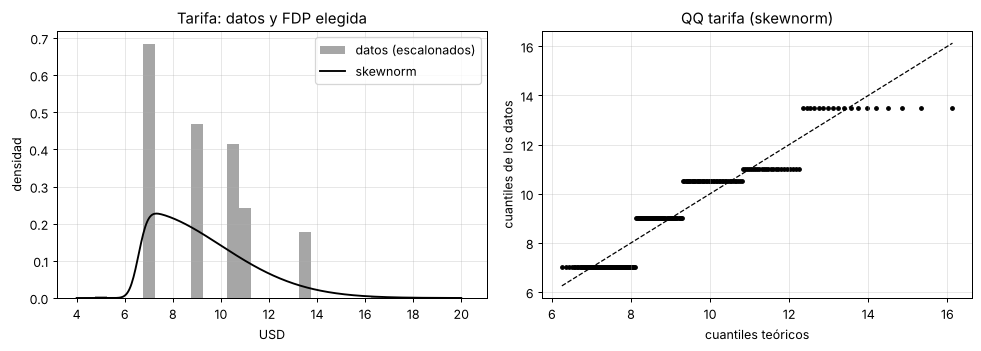

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(precios, bins=np.arange(4.75, 20.5, 0.5), density=True, color=GRIS, label="datos (escalonados)")
x = np.linspace(4, 20, 400)
ax1.plot(x, dist_t.pdf(x), "k", label=fam_t)
ax1.set(title="Tarifa: datos y FDP elegida", xlabel="USD", ylabel="densidad"); ax1.legend()
grafico_qq(ax2, precios, dist_t, f"QQ tarifa ({fam_t})")
plt.tight_layout(); plt.show()

muestra_t = verificar(dist_t, datos=precios, tol_media=5, tol_desvio=5)

El QQ tiene forma de escalera porque los datos son escalonados; los escalones quedan alrededor de la diagonal, lo que indica que la FDP ubica bien cada rango de precios.

## 8. Tiempo de viaje: se calcula, no se ajusta

El dataset no tiene duraciones. El notebook del TP4 las generaba con una velocidad aleatoria y después les ajustaba una FDP; eso solo devuelve la distribución que se usó para generarlas (modelo §4.3). El simulador calcula el tiempo de viaje de cada pedido a partir de su distancia:

**TV = D × 60 / v + DEM**, con v = 13 mi/h (supuesto S-06; validarlo con datos es de la segunda iteración).

Con las FDP elegidas quedan los valores de referencia del modelo (§4.4): el **tiempo medio de servicio** E[S], que es el tiempo que un chofer queda comprometido con un pedido, y la flota "actual", la menor que cubre la demanda media.

In [17]:
V_MPH = 13
e_tv = 60 * dist_d.mean() / V_MPH + dist_dem.mean()
e_s = dist_tb.mean() + e_tv
print(f"E[D] = {dist_d.mean():.4f} mi → E[TV] = 60 × {dist_d.mean():.4f} / {V_MPH} + {dist_dem.mean()} = {e_tv:.4f} min")
print(f"E[S] = E[TB] + E[TV] = {dist_tb.mean():.4f} + {e_tv:.4f} = {e_s:.4f} min")
for nivel, factor in niveles.items():
    carga = factor / MEDIA_IA_BASE * e_s
    print(f"Carga del nivel {nivel:5s}: λ × E[S] = {factor / MEDIA_IA_BASE:.2f} × {e_s:.2f} = {carga:.3f} choferes ocupados en promedio")
carga_base = e_s / MEDIA_IA_BASE
print(f"\nFlota actual = ⌈{carga_base:.3f}⌉ = {int(np.ceil(carga_base - 1e-9))} | flota peor = {int(np.ceil(carga_base - 1e-9)) - 1}")

E[D] = 2.1872 mi → E[TV] = 60 × 2.1872 / 13 + 0.8 = 10.8948 min
E[S] = E[TB] + E[TV] = 5.0000 + 10.8948 = 15.8948 min
Carga del nivel bajo : λ × E[S] = 0.28 × 15.89 = 4.451 choferes ocupados en promedio
Carga del nivel base : λ × E[S] = 0.40 × 15.89 = 6.358 choferes ocupados en promedio
Carga del nivel alto : λ × E[S] = 0.52 × 15.89 = 8.265 choferes ocupados en promedio

Flota actual = ⌈6.358⌉ = 7 | flota peor = 6


## 9. Catálogo para el simulador

El bloque siguiente se genera con los parámetros leídos de los ajustes, sin copiarlos a mano, en el formato del SDD (§5.6). La última celda comprueba que el archivo `config/fdp_v2.toml` del repositorio tiene exactamente estos valores.

In [18]:
def bloque(familia, params):
    pares = ", ".join(f"{n} = {float(v)!r}" for n, v in zip(nombres_parametros(familia), params))
    return f'tipo = "scipy"\nfamilia = "{familia}"\nparametros = {{ {pares} }}'

print(f'''[TB]
tipo = "scipy"
familia = "gamma"
parametros = {{ a = {a_tb!r}, scale = {escala_tb!r} }}

[D]
{bloque(fam_d, par_d)}

[DEM]
tipo = "scipy"
familia = "expon"
parametros = {{ scale = 0.8 }}

[TAR]
modo = "independiente"
{bloque(fam_t, par_t)}

[TAR.diagnostico]
n_filas = {len(precios)}
media_datos_usd = {float(precios.mean())!r}
desvio_datos_usd = {float(precios.std(ddof=1))!r}''')

[TB]
tipo = "scipy"
familia = "gamma"
parametros = { a = 11.111111111111112, scale = 0.45 }

[D]
tipo = "scipy"
familia = "weibull_min"
parametros = { c = 1.7369116327905525, loc = 0.3309934599319153, scale = 2.083267038112721 }

[DEM]
tipo = "scipy"
familia = "expon"
parametros = { scale = 0.8 }

[TAR]
modo = "independiente"
tipo = "scipy"
familia = "skewnorm"
parametros = { a = 11.302161887348964, loc = 6.577355813351607, scale = 3.403040560332343 }

[TAR.diagnostico]
n_filas = 47040
media_datos_usd = 9.281423894557824
desvio_datos_usd = 2.0661033973469776


In [19]:
import tomllib
with open(RUTA_CATALOGO, "rb") as f:
    catalogo = tomllib.load(f)

def mismos(seccion, familia, params):
    cat = catalogo[seccion]
    esperado = dict(zip(nombres_parametros(familia), params))
    return cat["familia"] == familia and all(np.isclose(cat["parametros"].get(k, 0 if k == "loc" else 1), v, rtol=0, atol=1e-12)
                                             for k, v in esperado.items())

print("Versión del catálogo:", catalogo["catalogo"]["version"])
print("Búsqueda igual al ajuste:  ", mismos("TB", "gamma", (a_tb, 0.0, escala_tb)))
print("Distancia igual al ajuste: ", mismos("D", fam_d, par_d))
print("Demora igual al supuesto:  ", mismos("DEM", "expon", (0.0, 0.8)))
print("Tarifa igual al ajuste:    ", mismos("TAR", fam_t, par_t))
print("Diagnóstico de la tarifa:  ", catalogo["TAR"]["diagnostico"]["n_filas"] == len(precios))

Versión del catálogo: V2
Búsqueda igual al ajuste:   True
Distancia igual al ajuste:  True
Demora igual al supuesto:   True
Tarifa igual al ajuste:     True
Diagnóstico de la tarifa:   True


## 10. Limitaciones y segunda iteración

**Limitaciones** (también en el modelo, §12.2):

- **Distancia y tarifa son escalonadas en los datos** (rutas fijas y tabla de precios) y se aproximan con FDP continuas. Reproducen bien la media y el desvío, pero no los escalones.
- **La tarifa no depende de la distancia** en la primera iteración (S-14): un viaje corto puede salir caro. La recaudación media es correcta.
- **El intervalo entre pedidos, la búsqueda, la demora y la velocidad son supuestos,** porque el dataset no tiene esa información.

**Para la segunda iteración** (modelo §12.3), sin cambiar la decisión de flota:

- tarifa según la distancia, por regresión, con el residuo ajustado con familias que admitan negativos (modelo §4.5.6);
- distribución empírica para la distancia, sorteando de los propios datos (modelo §4.5.1);
- validar la velocidad de 13 mi/h con datos de otra fuente (modelo §4.5.5).